## Simulating shapiro steps.
### 1. Simulation using RK4 integration of the differential equation
### 2. Resistively and Capacitively Shunted Junction (RCSJ) model

-------------
### Imports 

In [3]:

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import jv
import pandas as pd

## physical constants
e = 1.60218e-19
hbar = 1.05457e-34
h = 2*np.pi*hbar
Phi0 = h/(2*e)
kb = 1.380649e-23


----------------------
# 1. Shapiro steps simulation
## - Using RK4 integration, solves:
### $\frac{d\phi}{dt} = [I_{dc} + I_{rf} sin(\omega t) - I_c sin(\phi)] \frac{2eR_N}{\hbar}$


In [5]:
# Simulation parameters
dt = 5e-14
steps = 200000
transient = 50000


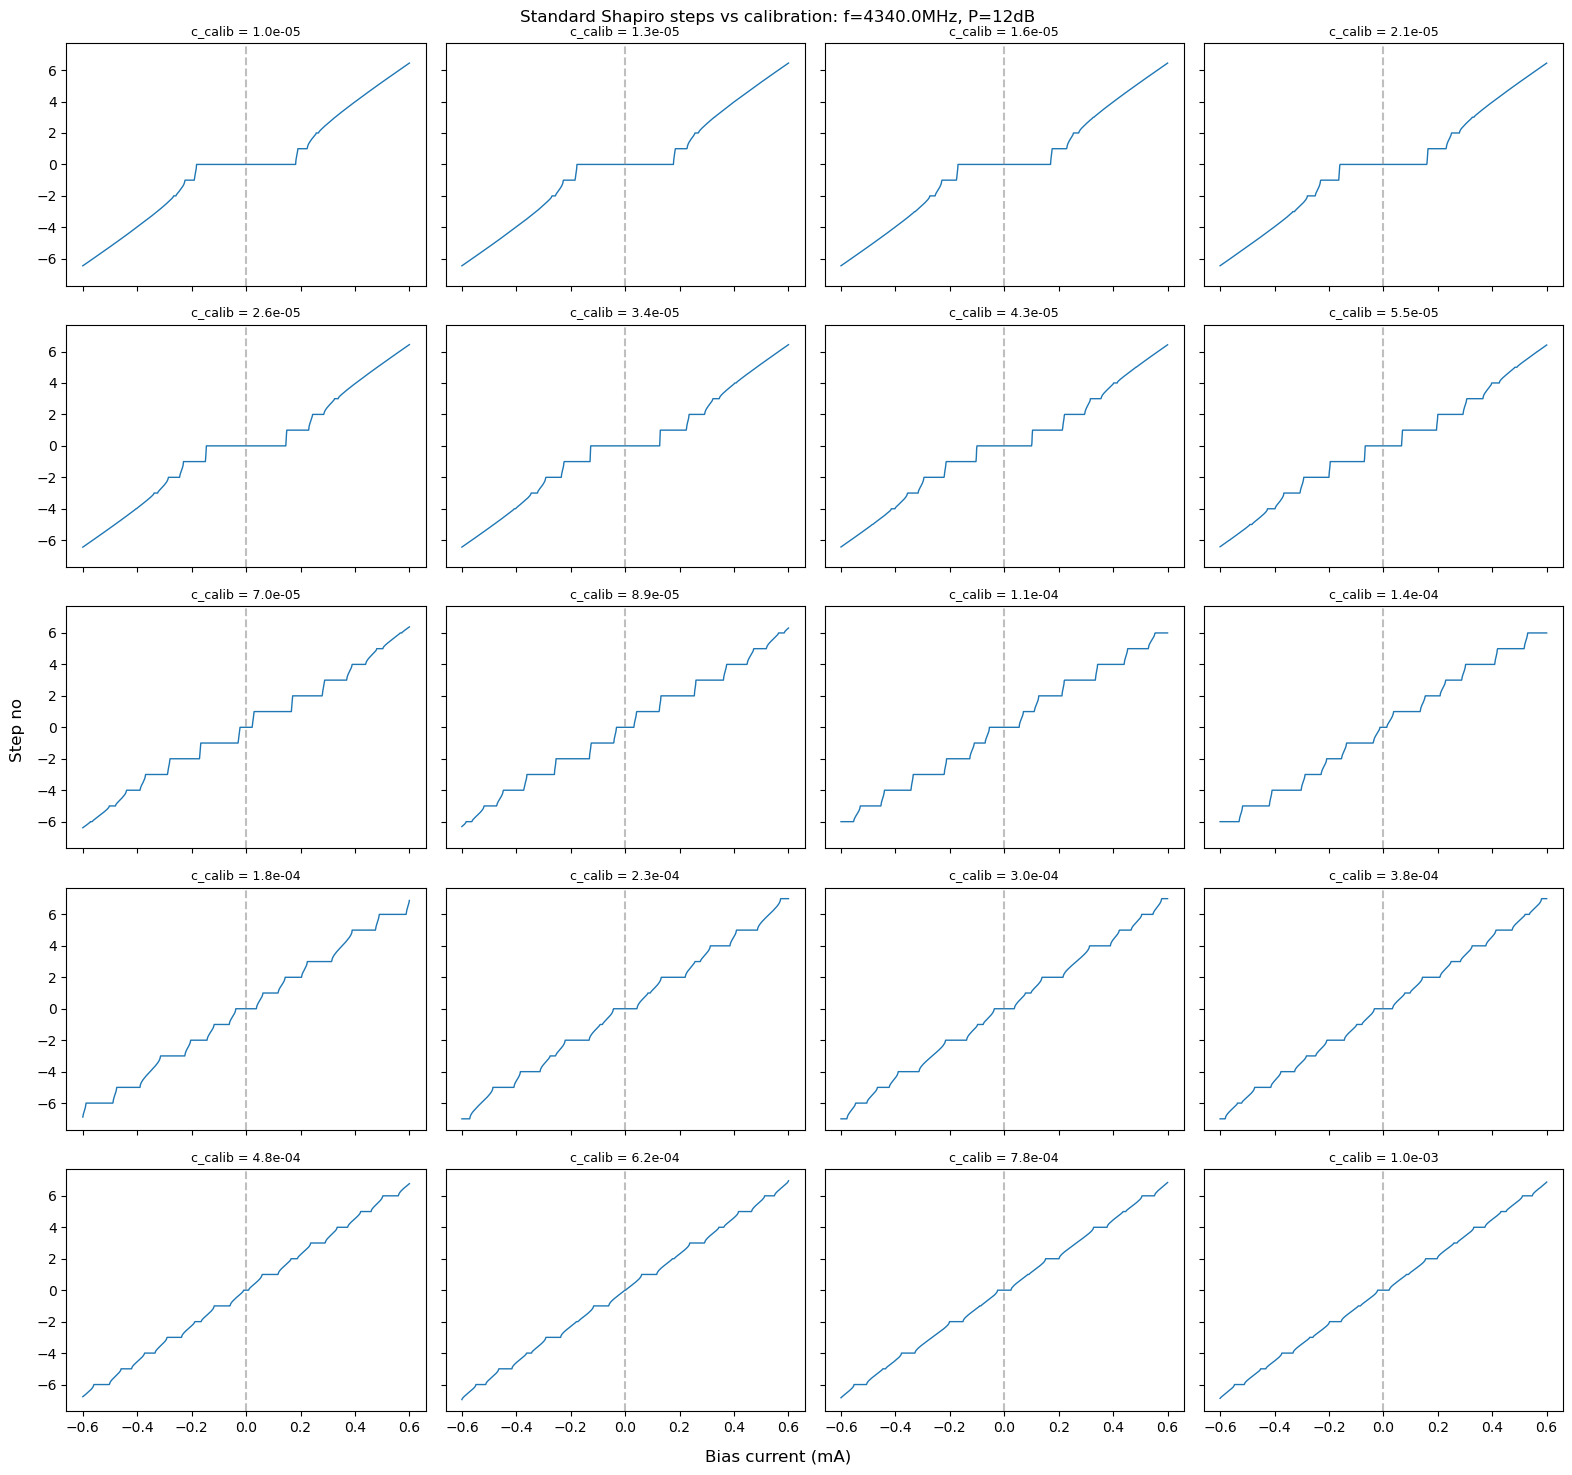

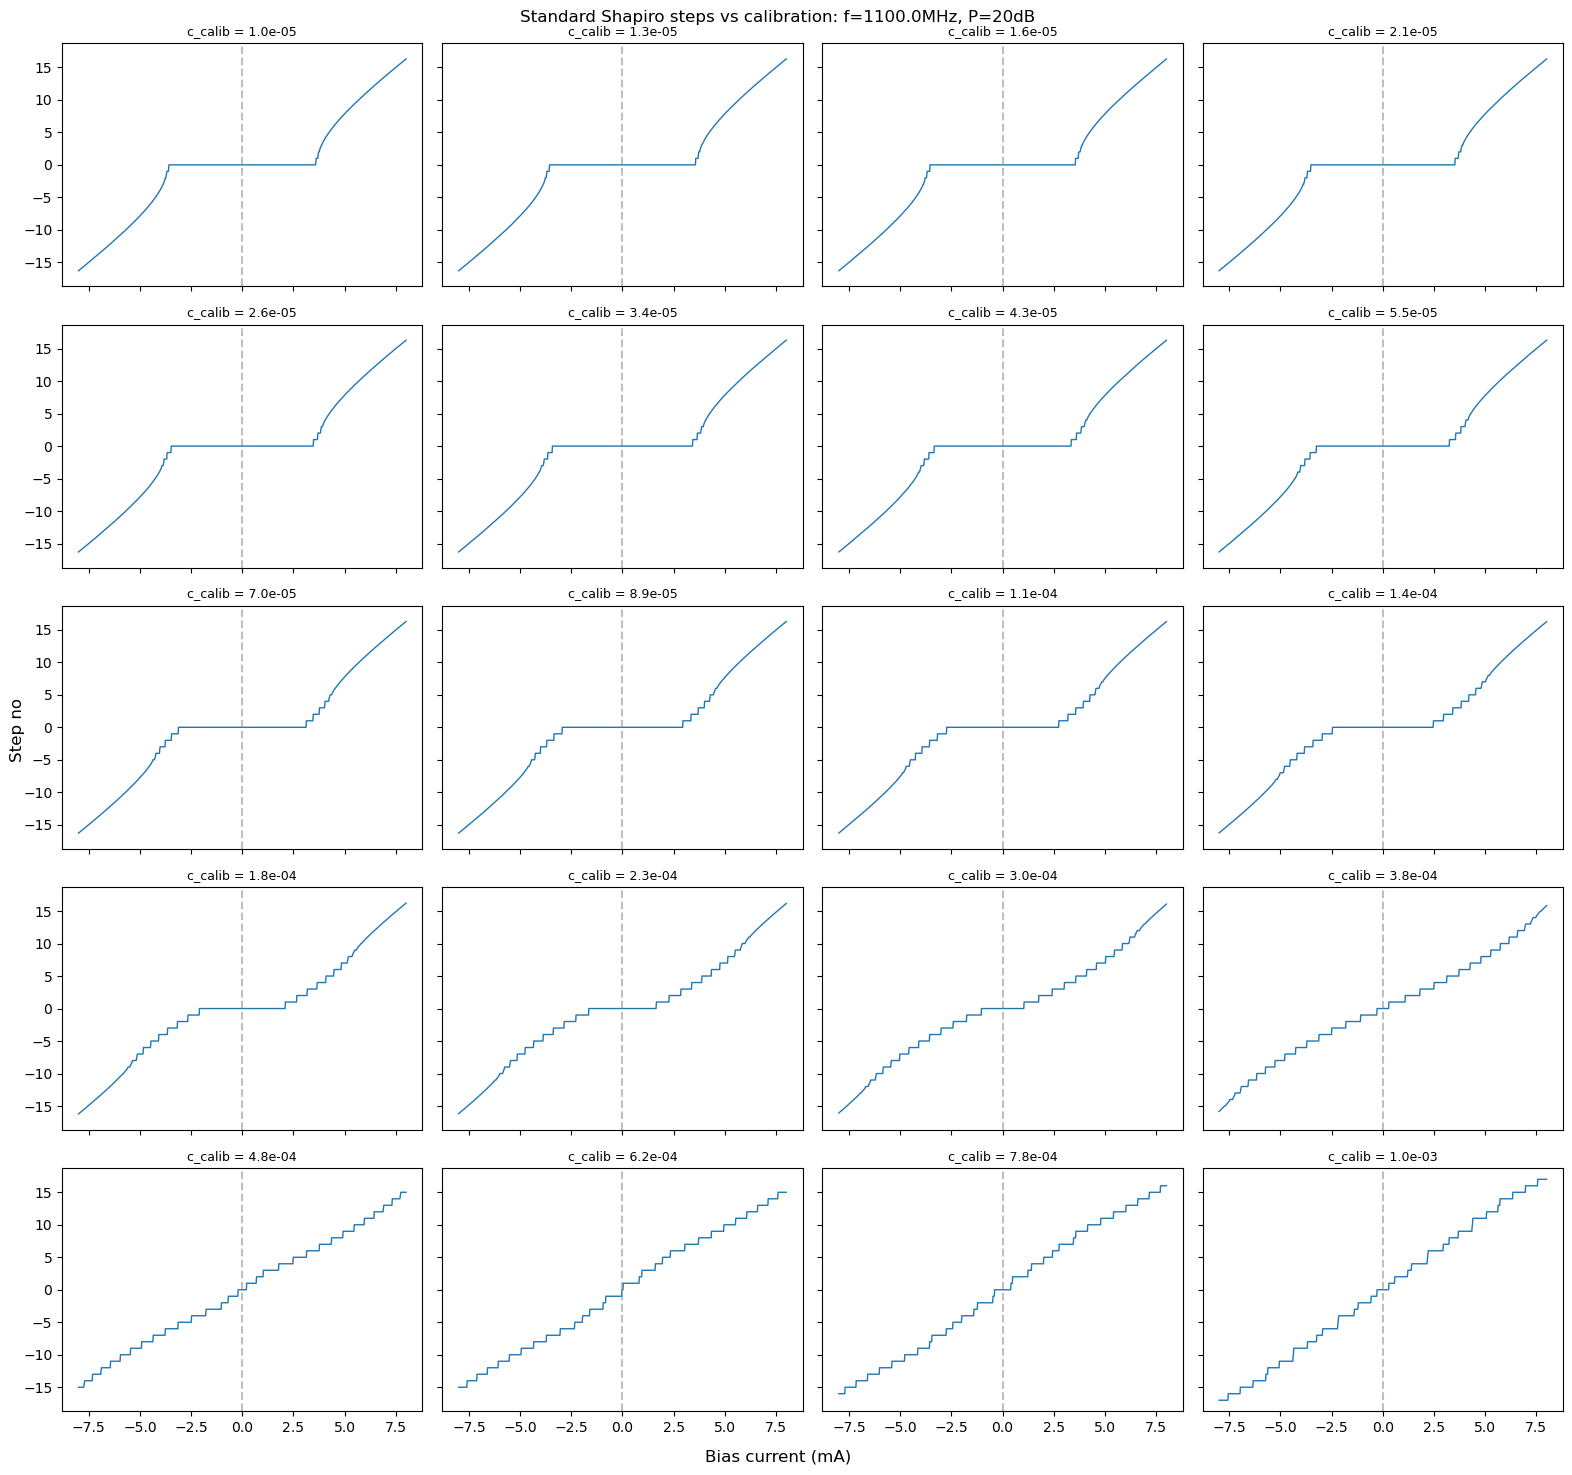

In [6]:

## old junction parameters #################################################################################

junction1 = dict(R=0.1017, I_crit=0.191e-3, frequency=4340e6, power=12,
                  I0=np.linspace(-0.6e-3, 0.6e-3, 1000))

junction2 = dict(R=0.0052, I_crit=3.63e-3, frequency=1100e6, power=20,
                  I0=np.linspace(-8e-3, 8e-3, 1000))

################## standard shapiro steps simulation #######################################################

def simulate_IV(junction, power, c_calib, n_periods,
                 steps_per_period=200, n_transient_periods=50):
    
    frequency = junction['frequency']
    I_crit = junction['I_crit']
    R = junction['R']
    I0 = junction['I0']
    
    def power_to_Irf(power, c_calib):
        return c_calib * 10**(power/20)     ## requires calibration: depends on how well coupled the wavesource is

    Irf_val = power_to_Irf(power, c_calib)  ## obtain the induces rf current
    
    omega = 2*np.pi*frequency
    
    dt = (1/frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)
    swept_idc = np.asarray(I0, dtype=float)
    phi = np.zeros_like(swept_idc)
    V_sum = np.zeros_like(swept_idc)
    count = 0
    t = 0.0
    
    def dphidt(t, phi):
        return (swept_idc + Irf_val*np.sin(omega*t) - I_crit*np.sin(phi)) * 2*e*R/hbar
        
    ## rk4 integration method
    for s in range(n_steps):
        k1 = dphidt(t, phi)
        k2 = dphidt(t + dt / 2, phi + dt / 2 * k1)
        k3 = dphidt(t + dt / 2, phi + dt / 2 * k2)
        k4 = dphidt(t + dt, phi + dt * k3)
        phi_new = phi + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        if s >= n_transient:
            V_sum += (phi_new - phi) / dt * (Phi0 / (2 * np.pi))
            count += 1
        phi = phi_new
        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2 * e) / (hbar * 2 * np.pi * frequency)

    return nth_step, v_avg     ## returns the step index and the average values of voltage

################# Simple plotting ################################################################

def plotting_steps(nth_step, junction):
    plt.figure(figsize = (10,8))
    plt.plot(junction['I0']*1e3, nth_step)
    plt.xlabel('Current (mA)')
    plt.ylabel('step number: 2eV/2πℏf')
    plt.title(f'IV curve. Parameters:\n f={junction['frequency']:.2f}, R={junction['R']:.2f} Ic={junction['I_crit']:.5f}')
    plt.show()

################# Sweep the calibration coefficient ################################################################

c_calibs1 = np.logspace(-5, -3, 20)   ## even spacing in log space. 20 vals from 1e-6 to 2e-6

def calibration_sweep(junction, c_calibs):
    '''
    sweep the calibration parameter c_calib
    - identify the value which returns the value required to produce the steps observed in the old data.
    '''
    ncols = 4
    nrows = int(np.ceil(len(c_calibs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, calib in zip(axes, c_calibs):
        step_no, v = simulate_IV(junction, junction['power'], calib, n_periods=200,
                 steps_per_period=200, n_transient_periods=50)
        ax.plot(junction['I0']*1e3, step_no, color='tab:blue', lw=1)
        ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
        ax.set_title(f"c_calib = {calib:.1e}", fontsize=9)

    for ax in axes[len(c_calibs):]:
        ax.set_visible(False)
    fig.supxlabel("Bias current (mA)")
    fig.supylabel("Step no")
    fig.suptitle(f"Standard Shapiro steps vs calibration: f={junction['frequency']/1e6}MHz, P={junction['power']}dB")
    plt.tight_layout()
    plt.show()

################# junction 1 plots ################################################################
calibration_sweep(junction1, c_calibs1)

################# junction 2 plots ################################################################
c_calibs2 = np.logspace(-5, -3, 20)   ## even spacing in log space. 20 vals from 1e-6 to 2e-6
calibration_sweep(junction2, c_calibs1)

In [7]:
c_calib1n = 1.6e-5
c_calib2n = 3e-4


## Extract shapiro step widths ###########################################
def extract_shapiro_widths(junction, nth_step, tol=0.05, min_points=3):
    '''
    parameters:
    - input junction parameters
    - step index
    - tolerance: determines the tolerance for which the steps are determined
    - min_points: minimum number of points that can be attributed to each step
    '''

    I0 = np.asarray(junction['I0'])
    nth_step = np.asarray(nth_step)

    nearest_n = np.round(nth_step)
    residual = np.abs(nth_step - nearest_n)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue
        n_val = nearest_n[i]
        j = i
        while j < N and on_plateau[j] and nearest_n[j] == n_val:
            j += 1
        
        if (j - i) >= min_points:
            I0_min = I0[i]
            I0_max = I0[j - 1]
            width = I0_max - I0_min
            
            if n_val not in widths or width > widths[n_val]:
                widths[n_val] = width
                ranges[n_val] = (I0_min, I0_max)
        i = j

    return widths, ranges



## 2. RCSJ model
### Solves:
$ \frac{d^2\phi}{dt^2} = [I_{dc} + I_rf sin(\omega t) - I_c sin(\phi) + \frac{\hbar}{2e R_N} \frac{d\phi}{dt} - I_N - I_F]\frac{2e}{\hbar C} $

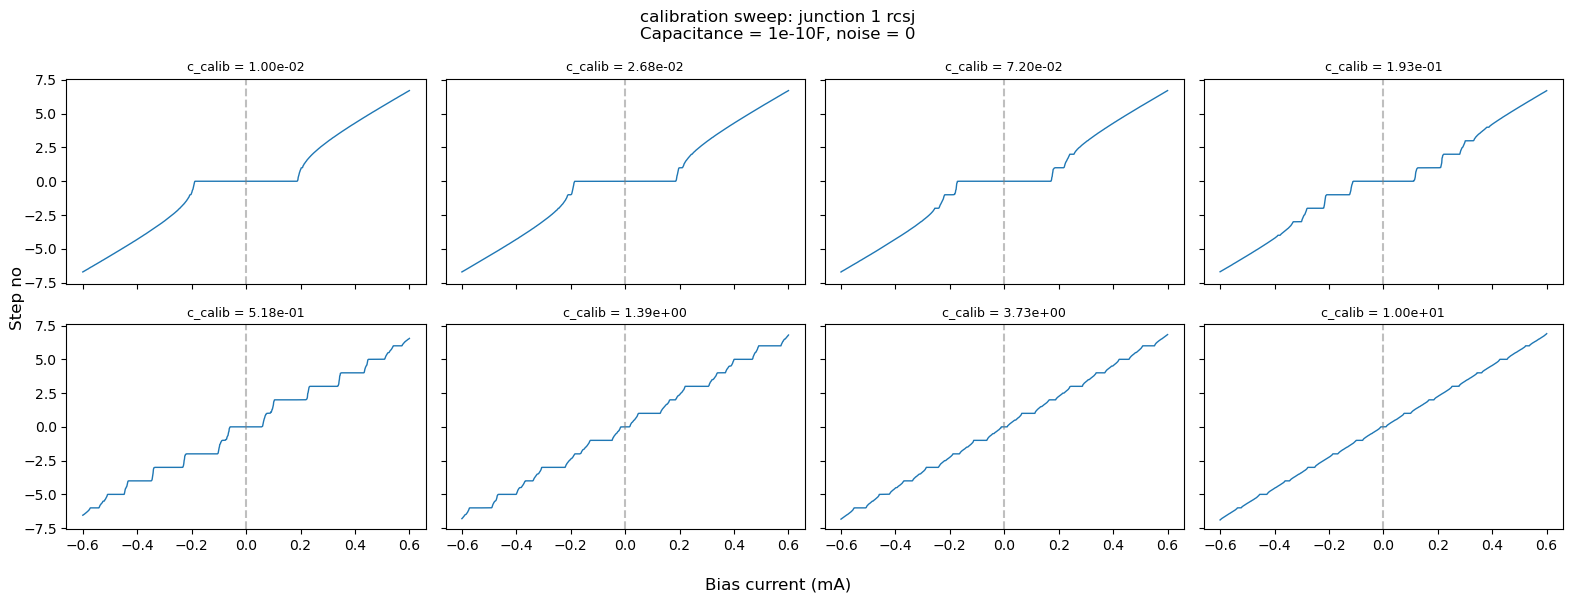

In [9]:
########### Resistively and capacitively shunted junction model ######################################

def simulate_IV_RCSJ(junction, power, c_calib,
                     C, T, noise, n_periods,
                     steps_per_period=200, n_transient_periods=50):
    frequency = junction['frequency']
    I_crit = junction['I_crit']
    R = junction['R']
    I0 = junction['I0']
    
    Irf_val = c_calib * I_crit * 10**((power)/20)          ## drive current corresponding to power

    dt = (1 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0
    
    noise_T = np.sqrt(2 * kb * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_N = noise_T * np.random.randn(I0.size) if T > 0 else 0.0      ## thermal noise term. random
        I_F = noise * np.random.randn(len(I0)) * (I0 + Irf_val / 1000)  ## randomly fluctuating noise term

        I_drive = I0 + Irf_val * np.sin(2 * np.pi * frequency * t) \
                  - I_crit * np.sin(phi) + I_N + I_F

        if C > 0:
            d2phidt2 = (2 * e / (hbar * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        else:
            dphidt = (2 * e * R / hbar) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (hbar / (2 * e)) * dphidt
            count += 1
        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2 * e) / (hbar * 2 * np.pi * frequency)

    return nth_step, v_avg

######## check the calibration ################################################################################

def plot_calibration_sweepRCSJ(model, junction, capacitance, noise, c_calibs, title,
                               T, n_periods,
                               steps_per_period=200, n_transient_periods=50):
    '''
    modified calibration sweep function: includes option for whether RCSJ or standard model is used.
    returns: none
    '''
    ncols = 4
    nrows = int(np.ceil(len(c_calibs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
    axes = axes.flatten()
    power = junction['power']

    ########### if using rcsj model ####################################
    if model == 'rcsj':
        for ax, calib in zip(axes, c_calibs):
            step_no, _ = simulate_IV_RCSJ(
                junction, power,
                c_calib=calib,
                C=capacitance, T=T, noise=noise,
                n_periods=n_periods,
                steps_per_period=steps_per_period,
                n_transient_periods=n_transient_periods)
            ax.plot(junction["I0"]*1e3, step_no, color='tab:blue', lw=1)
            ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
            ax.set_title(f"c_calib = {calib:.2e}", fontsize=9)

    ########### if using standard model ####################################
    else:
        for ax, calib in zip(axes, c_calibs):
            step_no, v = simulate_IV(junction, power, 
                                     calib, 
                                     n_periods=200,
                                  steps_per_period=200, n_transient_periods=50)
            ax.plot(junction["I0"]*1e3, step_no, color='tab:blue', lw=1)
            ax.axvline(0, linestyle='--', color='gray', alpha=0.5)
            ax.set_title(f"c_calib = {calib:.2e}", fontsize=9)

    for ax in axes[len(c_calibs):]:
        ax.set_visible(False)

    fig.supxlabel("Bias current (mA)")
    fig.supylabel("Step no")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

c_calibs_c = np.logspace(-2, 1, 8)

## example: using small capacitance to check whether the model works.
plot_calibration_sweepRCSJ('rcsj', junction1, capacitance=1e-10, noise=0, c_calibs=c_calibs_c, title='calibration sweep: junction 1 rcsj\nCapacitance = 1e-10F, noise = 0',
                           T=4, 
                           n_periods=200,
                           steps_per_period=200, n_transient_periods=50)



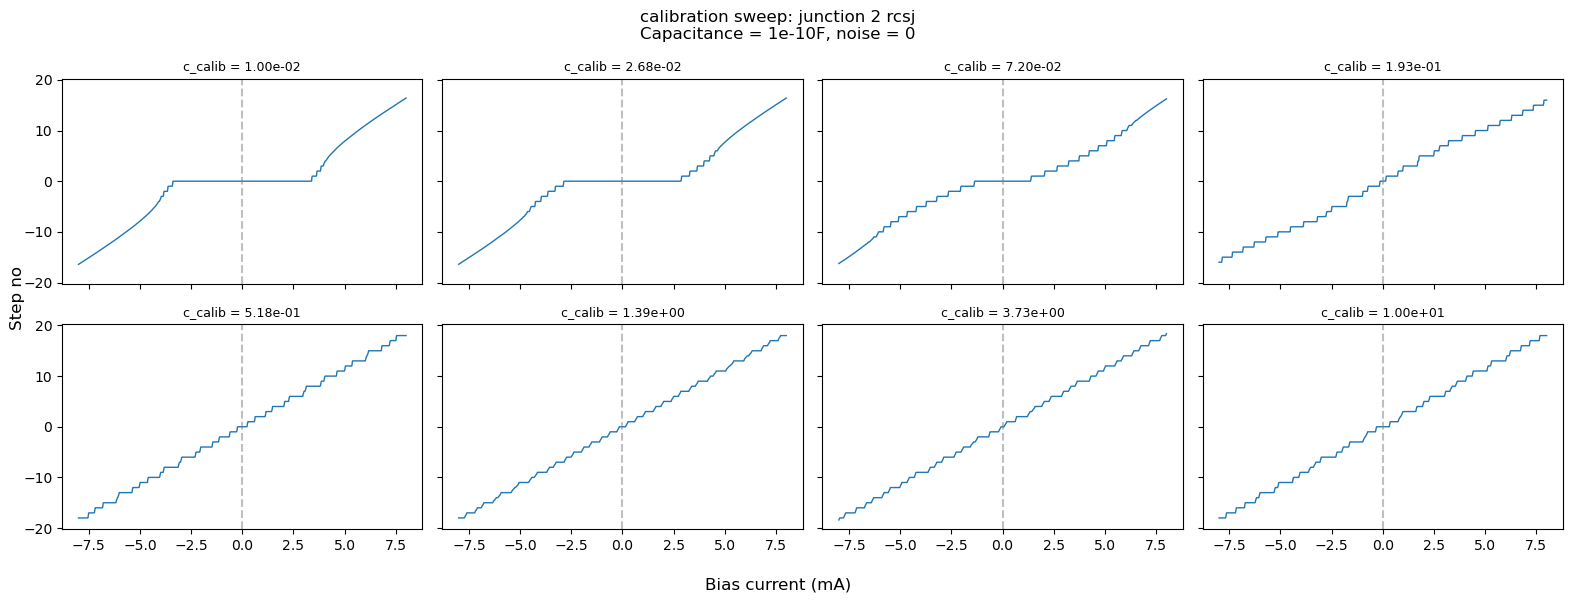

In [10]:
plot_calibration_sweepRCSJ('rcsj', junction2, capacitance=1e-9, noise=0, c_calibs=c_calibs_c, title= 'calibration sweep: junction 2 rcsj\nCapacitance = 1e-10F, noise = 0',
                           T=4,                  
                           n_periods=200,
                           steps_per_period=200, n_transient_periods=50)


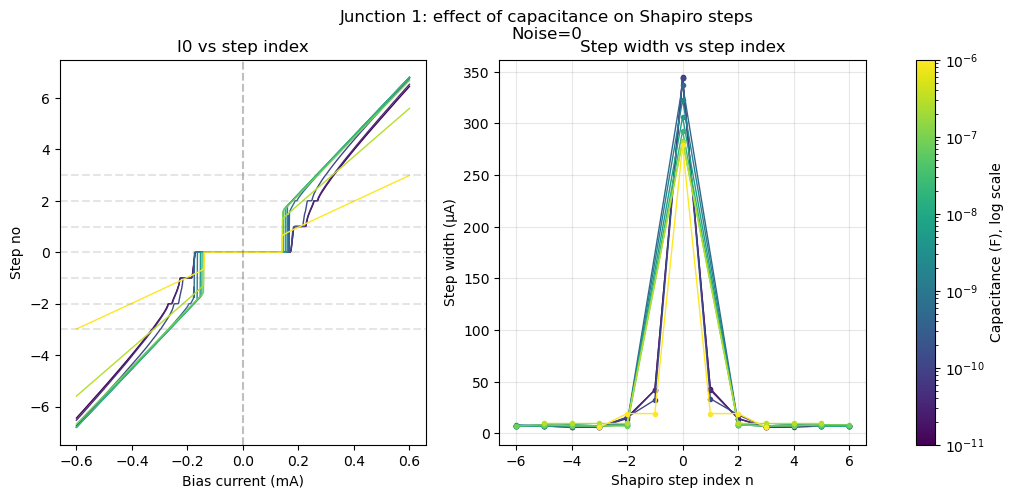

/var/folders/1w/q2zvlnpd1y51bxy8ps57kl540000gn/T/ipykernel_47655/2583961400.py:34: RuntimeWarning: overflow encountered in divide
  d2phidt2 = (2 * e / (hbar * C)) * I_drive - dphidt / (R * C)
/var/folders/1w/q2zvlnpd1y51bxy8ps57kl540000gn/T/ipykernel_47655/2583961400.py:31: RuntimeWarning: invalid value encountered in sin
  - I_crit * np.sin(phi) + I_N + I_F


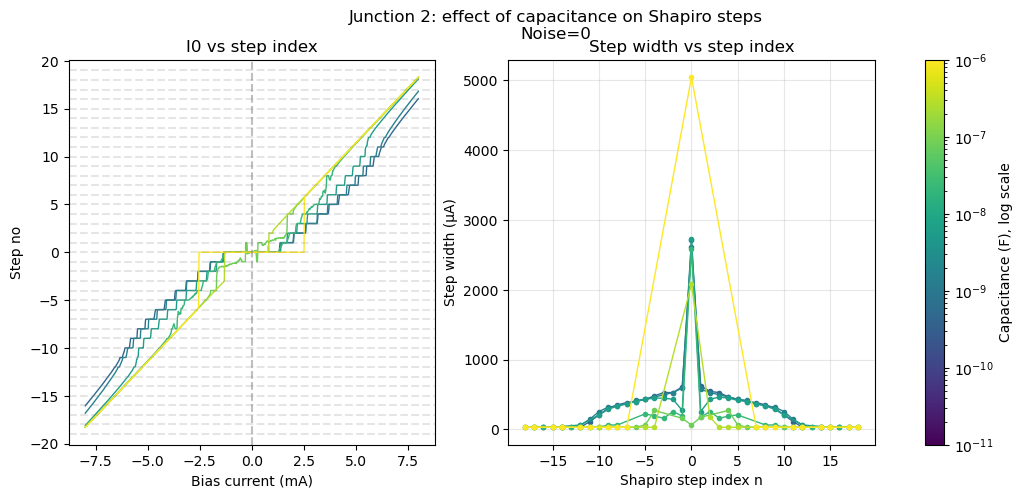

In [11]:
c_calib1 = 7.2e-2
c_calib2 = 7.2e-2

import matplotlib.cm as cm
import matplotlib.colors as mcolors

def beta_c(I, R, C):
    '''
    returns the Stewart-McCumber parameter.
    - defines the damping of the junction.
    - overdamped regime: Beta_c < 1
    - underdamped regime: Beta_c >> 1
    '''
    return I * R**2 * C * 2 * e / hbar

def capacitance_sweep(junction, c_calib, capacitances, T, noise, 
                       tol=0.05, min_points=3, title="Capacitance sweep"):
    '''
    change the capacitance and plot the shapiro steps for each value.
    
    '''
    R = junction["R"]
    I_crit = junction["I_crit"]
    I0 = junction['I0']
    power = junction['power']

    beta_vals = np.array([beta_c(I_crit, R, C) for C in capacitances])      ## determines the stewart-mccumber parameter

    colormap = cm.viridis
    norm = mcolors.LogNorm(vmin=capacitances.min(), vmax=capacitances.max())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    all_widths = {} 

    ## simulate the shapiro steps for each value  of capacitance
    for C in capacitances:
        steps, _ = simulate_IV_RCSJ(junction, power, c_calib,
                     C, T, noise, n_periods=500,
                     steps_per_period=200, n_transient_periods=50)

        color = colormap(norm(C))

        # I0 vs n curve
        ax1.plot(I0 * 1e3, steps, lw=1, color=color)

        ## extract widths for each C value and store 
        widths, ranges = extract_shapiro_widths(junction, steps,
                                                  tol=tol, min_points=min_points)
        all_widths[C] = widths

        if widths:
            ns = sorted(widths)
            w_uA = [widths[n] * 1e6 for n in ns]
            ax2.plot(ns, w_uA, 'o-', lw=1, ms=3, color=color)

    ax1.axvline(0, linestyle='--', color='gray', alpha=0.5)
    integers = range(int(np.floor(np.min(steps))), int(np.ceil(np.max(steps))) + 1)
    for line in integers:
        ax1.axhline(line, linestyle='--', color='gray', alpha=0.2)
    ax1.set_xlabel("Bias current (mA)")
    ax1.set_ylabel("Step no")
    ax1.set_title("I0 vs step index")

    ax2.set_xlabel("Shapiro step index n")
    ax2.set_ylabel("Step width (µA)")
    ax2.set_title("Step width vs step index")
    ax2.grid(True, alpha=0.3)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax1, ax2])
    cbar.set_label("Capacitance (F), log scale")

    fig.suptitle(title)
    plt.show()

    return all_widths


## Practice run: iterate over different values of capacitance
## T = 4K 
## No noise (just to check initial shape)

capacitances = np.logspace(-11, -6, 10)  
all_widths = capacitance_sweep(junction1, c_calib1, 
                               capacitances, 
                               T= 4, 
                               noise = 0,
                               title=f"Junction 1: effect of capacitance on Shapiro steps\nNoise=0")

all_widths2 = capacitance_sweep(junction2, c_calib2, 
                                capacitances, 
                                T= 4, 
                                noise = 0,
                                title=f"Junction 2: effect of capacitance on Shapiro steps\nNoise=0")


capacitance:3.331876023645596e-10, regime=underdamped
capacitance:8.32969005911399e-11, regime=overdamped


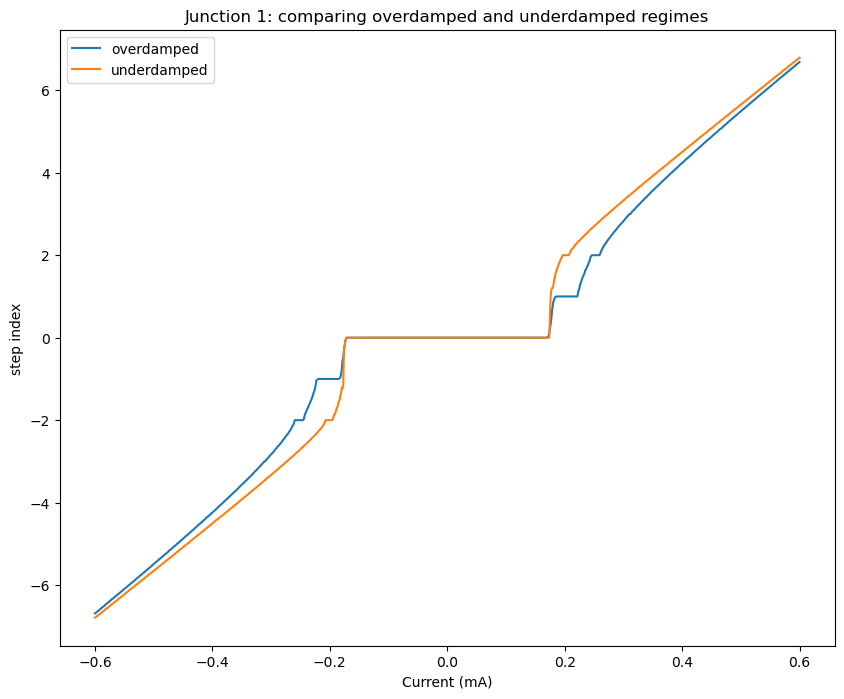

capacitance:6.705803051071086e-09, regime=underdamped
capacitance:1.6764507627677716e-09, regime=overdamped


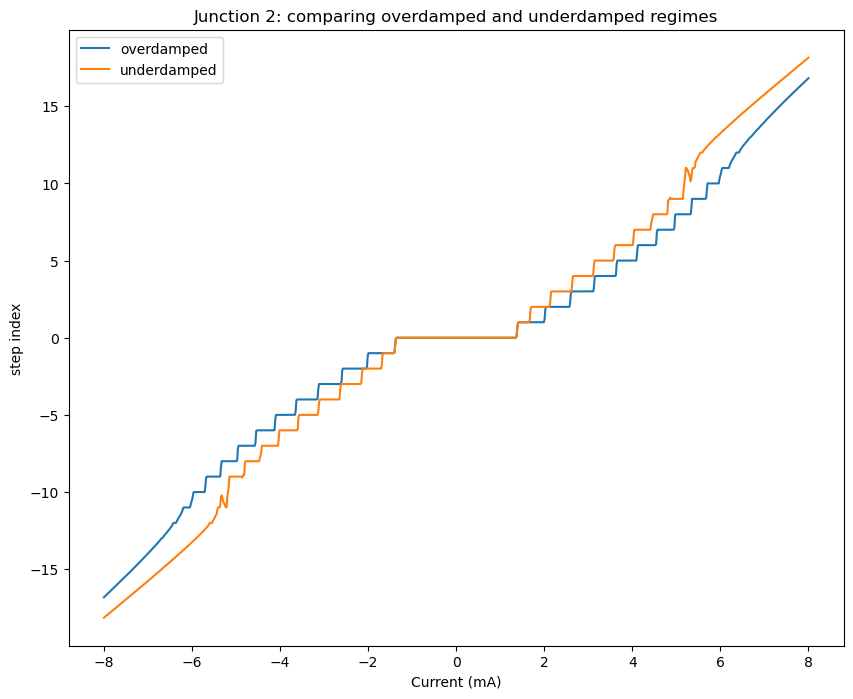

In [12]:
def capacitance_bc(beta, Ic, Rn):
    C_beta = (beta * hbar) / (2 * e * Ic * Rn**2)
    regime = 'underdamped' if beta > 1 else 'overdamped'
    return C_beta, regime

C_under1, regime1 = capacitance_bc(2, junction1['I_crit'], junction1['R'])
print(f'capacitance:{C_under1}, regime={regime1}')
C_over1, regime1 = capacitance_bc(0.5, junction1['I_crit'], junction1['R'])
print(f'capacitance:{C_over1}, regime={regime1}')
n_steps_under1, _ = simulate_IV_RCSJ(junction1, junction1['power'], c_calib1,
                                 C = C_under1, 
                                 T= 4, 
                                 noise= 0, 
                                 n_periods=200,
                                 steps_per_period=200, n_transient_periods=50)
n_steps_over1, _ = simulate_IV_RCSJ(junction1, junction1['power'], c_calib1,
                                 C = C_over1, 
                                 T= 4, 
                                 noise= 0, 
                                 n_periods=200,
                                 steps_per_period=200, n_transient_periods=50)
plt.figure(figsize=(10,8))
plt.plot(junction1['I0']*1e3, n_steps_over1, label='overdamped')
plt.plot(junction1['I0']*1e3, n_steps_under1, label='underdamped')
plt.xlabel('Current (mA)')
plt.ylabel('step index')
plt.title('Junction 1: comparing overdamped and underdamped regimes')
plt.legend()
plt.show()



C_under2, regime2 = capacitance_bc(2, junction2['I_crit'], junction2['R'])
print(f'capacitance:{C_under2}, regime={regime2}')
C_over2, regime2 = capacitance_bc(0.5, junction2['I_crit'], junction2['R'])
print(f'capacitance:{C_over2}, regime={regime1}')
n_steps_under2, _ = simulate_IV_RCSJ(junction2, junction2['power'], c_calib2,
                                 C = C_under2, 
                                 T= 4, 
                                 noise= 0, 
                                 n_periods=200,
                                 steps_per_period=200, n_transient_periods=50)
n_steps_over2, _ = simulate_IV_RCSJ(junction2, junction2['power'], c_calib2,
                                 C = C_over2, 
                                 T= 4, 
                                 noise= 0, 
                                 n_periods=200,
                                 steps_per_period=200, n_transient_periods=50)
plt.figure(figsize=(10,8))
plt.plot(junction2['I0']*1e3, n_steps_over2, label='overdamped')
plt.plot(junction2['I0']*1e3, n_steps_under2, label='underdamped')
plt.xlabel('Current (mA)')
plt.ylabel('step index')
plt.title('Junction 2: comparing overdamped and underdamped regimes')
plt.legend()
plt.show()

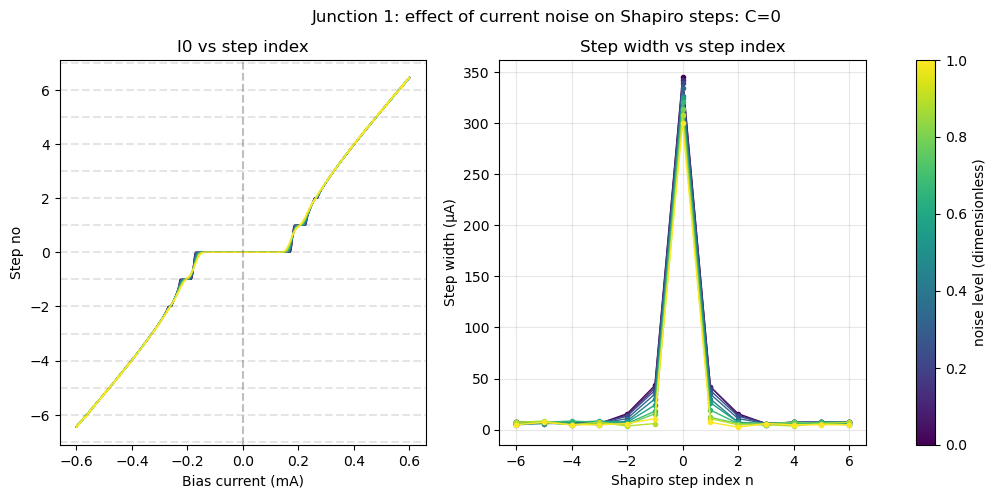

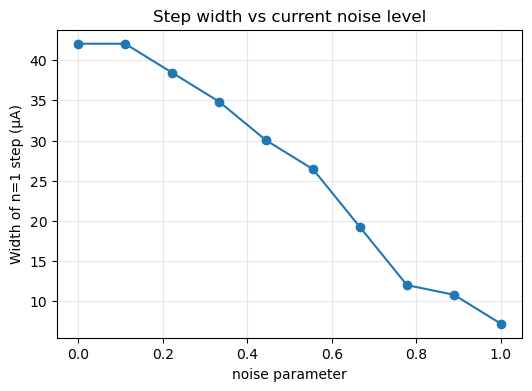

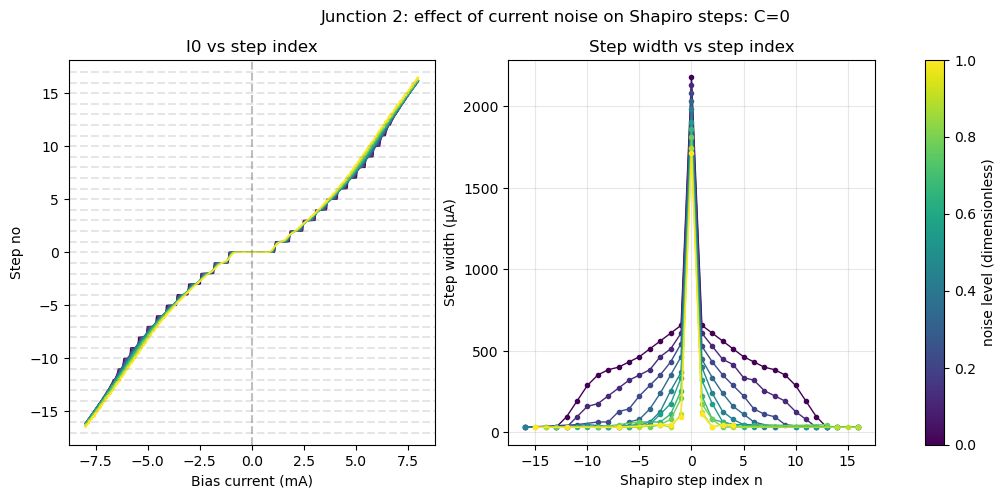

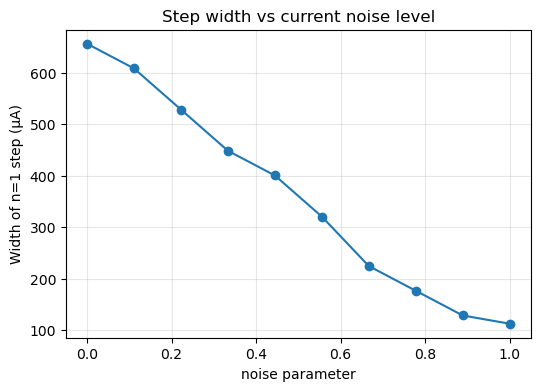

In [13]:
## Sweep the noise
## Changing the noise level ############################################

def noise_sweep(junction, c_calib, noises,
                 tol=0.05, min_points=3, title="Noise sweep"):
    """
    Sweep the multiplicative current-noise parameter `noise` and plot:
      1) I0 vs step index curves, colored by noise level
      2) step width vs step index, colored by noise level
    """
    R = junction["R"]
    I_crit = junction["I_crit"]
    I0 = junction['I0']
    power = junction['power']

    colormap = cm.viridis
    norm = mcolors.Normalize(vmin=noises.min(), vmax=noises.max())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    all_widths = {} 

    for noise_val in noises:
        steps, _ = simulate_IV_RCSJ(junction, power, c_calib,
                     C=0, T=4, noise=noise_val, n_periods=500,
                     steps_per_period=200, n_transient_periods=50)

        color = colormap(norm(noise_val))

        ax1.plot(I0 * 1e3, steps, lw=1, color=color)

        ## extract widths for this noise level and store
        widths, ranges = extract_shapiro_widths(junction, steps,
                                                  tol=tol, min_points=min_points)
        all_widths[noise_val] = widths

        if widths:
            step_ns = sorted(widths)
            w_uA = [widths[k] * 1e6 for k in step_ns]
            ax2.plot(step_ns, w_uA, 'o-', lw=1, ms=3, color=color)

    ax1.axvline(0, linestyle='--', color='gray', alpha=0.5)
    integers = range(int(np.floor(np.min(steps))), int(np.ceil(np.max(steps))) + 1)
    for line in integers:
        ax1.axhline(line, linestyle='--', color='gray', alpha=0.2)
    ax1.set_xlabel("Bias current (mA)")
    ax1.set_ylabel("Step no")
    ax1.set_title("I0 vs step index")

    ax2.set_xlabel("Shapiro step index n")
    ax2.set_ylabel("Step width (µA)")
    ax2.set_title("Step width vs step index")
    ax2.grid(True, alpha=0.3)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax1, ax2])
    cbar.set_label("noise level (dimensionless)")

    fig.suptitle(title)
    plt.show()

    n_check = 1
    noise_keys = sorted(all_widths.keys())
    w1 = [all_widths[nv].get(n_check, np.nan) * 1e6 for nv in noise_keys]

    plt.figure(figsize=(6,4))
    plt.plot(noise_keys, w1, 'o-')
    plt.xlabel('noise parameter')
    plt.ylabel(f'Width of n={n_check} step (µA)')
    plt.title('Step width vs current noise level')
    plt.grid(True, alpha=0.3)
    plt.show()

    return all_widths

noises = np.linspace(0, 1, 10)
widths1n = noise_sweep(junction1, c_calib1, noises,
                            title="Junction 1: effect of current noise on Shapiro steps: C=0")

c_calib2 = 8e-2
widths2n = noise_sweep(junction2, c_calib2, noises,
                            title="Junction 2: effect of current noise on Shapiro steps: C=0")

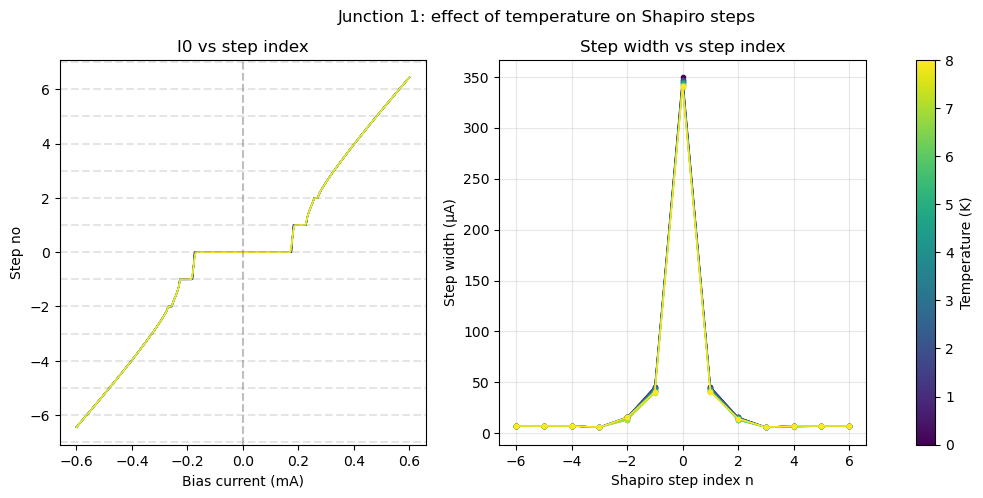

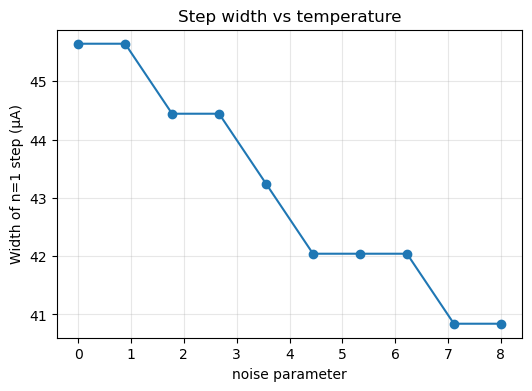

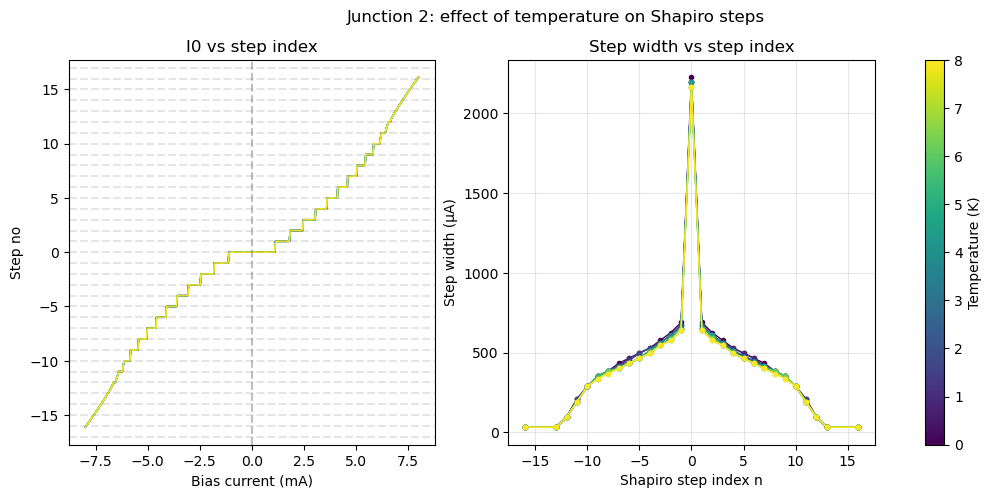

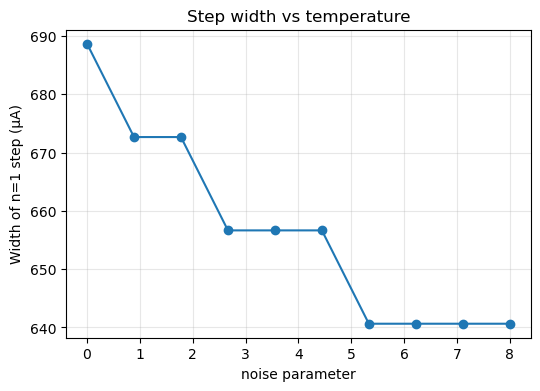

In [14]:
## sweep the temperature

def temp_sweep(junction, c_calib, temperatures,
                 tol=0.05, min_points=3, title="Noise sweep"):
    """
    Sweep the multiplicative current-noise parameter `noise` and plot:
      1) I0 vs step index curves, colored by noise level
      2) step width vs step index, colored by noise level
    """
    R = junction["R"]
    I_crit = junction["I_crit"]
    I0 = junction['I0']
    power = junction['power']

    colormap = cm.viridis
    norm = mcolors.Normalize(vmin=temperatures.min(), vmax=temperatures.max())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    all_widths = {} 

    for temp in temperatures:
        steps, _ = simulate_IV_RCSJ(junction, power, c_calib,
                     C=0, T=temp, noise=0, n_periods=500,
                     steps_per_period=200, n_transient_periods=50)

        color = colormap(norm(temp))

        ax1.plot(I0 * 1e3, steps, lw=1, color=color)

        widths, ranges = extract_shapiro_widths(junction, steps,
                                                  tol=tol, min_points=min_points)
        all_widths[temp] = widths

        if widths:
            step_ns = sorted(widths)
            w_uA = [widths[k] * 1e6 for k in step_ns]
            ax2.plot(step_ns, w_uA, 'o-', lw=1, ms=3, color=color)

    ax1.axvline(0, linestyle='--', color='gray', alpha=0.5)
    integers = range(int(np.floor(np.min(steps))), int(np.ceil(np.max(steps))) + 1)
    for line in integers:
        ax1.axhline(line, linestyle='--', color='gray', alpha=0.2)
    ax1.set_xlabel("Bias current (mA)")
    ax1.set_ylabel("Step no")
    ax1.set_title("I0 vs step index")

    ax2.set_xlabel("Shapiro step index n")
    ax2.set_ylabel("Step width (µA)")
    ax2.set_title("Step width vs step index")
    ax2.grid(True, alpha=0.3)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax1, ax2])
    cbar.set_label("Temperature (K)")

    fig.suptitle(title)
    plt.show()

    n_check = 1
    noise_keys = sorted(all_widths.keys())
    w1 = [all_widths[nv].get(n_check, np.nan) * 1e6 for nv in noise_keys]

    plt.figure(figsize=(6,4))
    plt.plot(noise_keys, w1, 'o-')
    plt.xlabel('noise parameter')
    plt.ylabel(f'Width of n={n_check} step (µA)')
    plt.title('Step width vs temperature')
    plt.grid(True, alpha=0.3)
    plt.show()

    return all_widths


temperatures = np.linspace(0, 8, 10)
widthsT1 = temp_sweep(junction1, c_calib1, temperatures,
                                 title="Junction 1: effect of temperature on Shapiro steps")

widthsT2 = temp_sweep(junction2, c_calib2, temperatures,
                                 title="Junction 2: effect of temperature on Shapiro steps")



In [15]:
### Topological junction

=== ratio 4:1 (I_crit1 : I_crit2), noise/thermal OFF ===


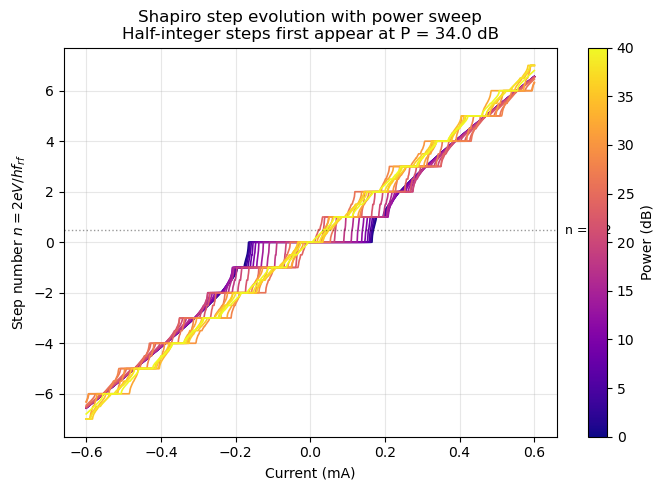

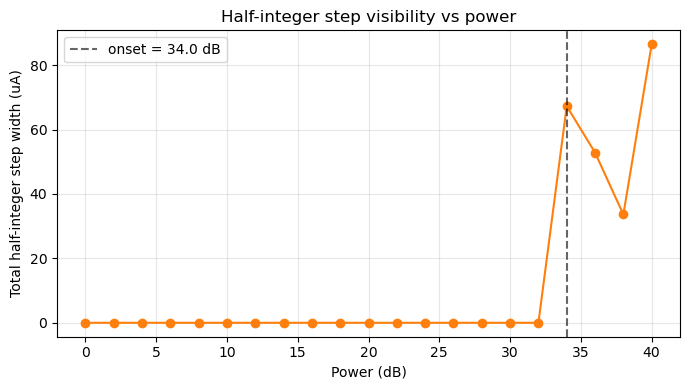

Half-integer steps first appear (and stay flat) around P = 34.0 dB.
=== ratio 3:2 (I_crit1 : I_crit2), noise/thermal OFF ===


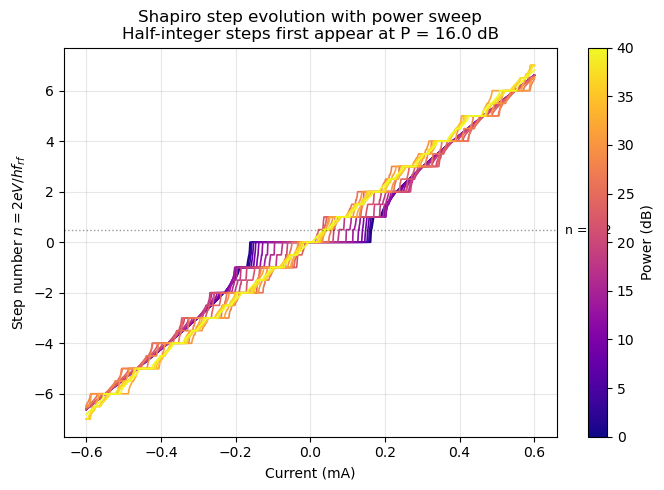

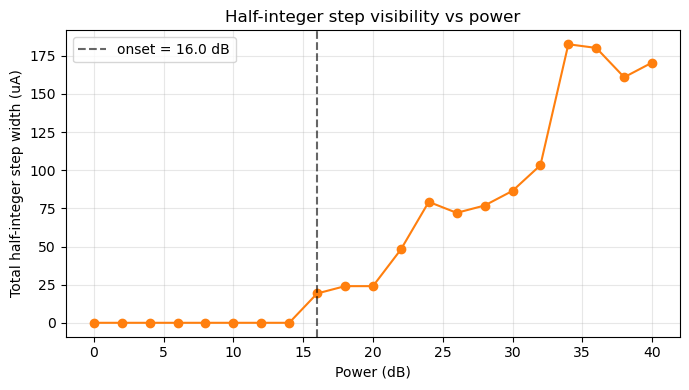

Half-integer steps first appear (and stay flat) around P = 16.0 dB.


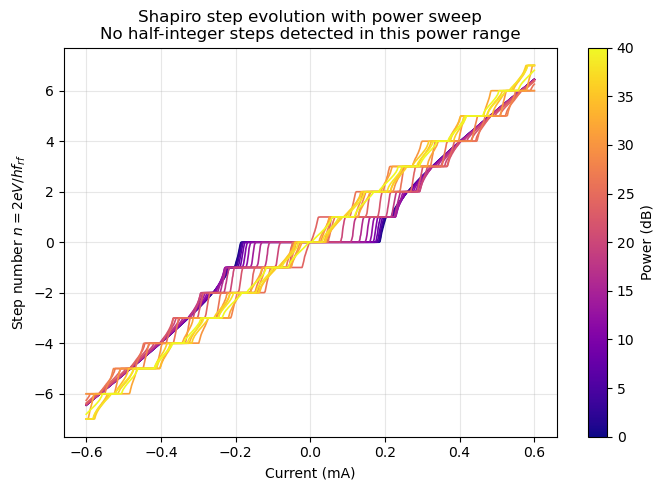

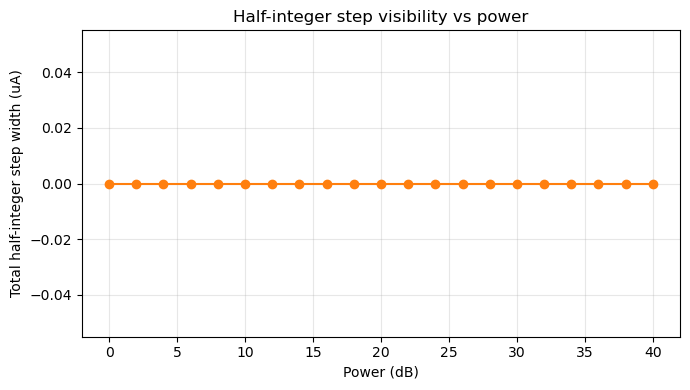

No half-integer steps detected in this power range.
Ratio I2/I_total = 0.00 → no visible half steps


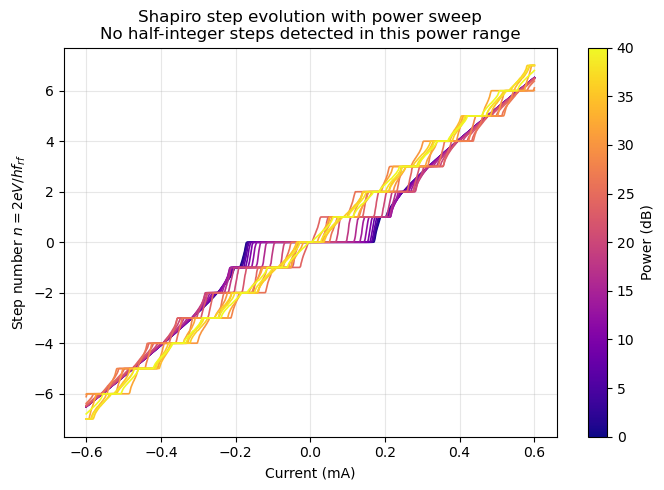

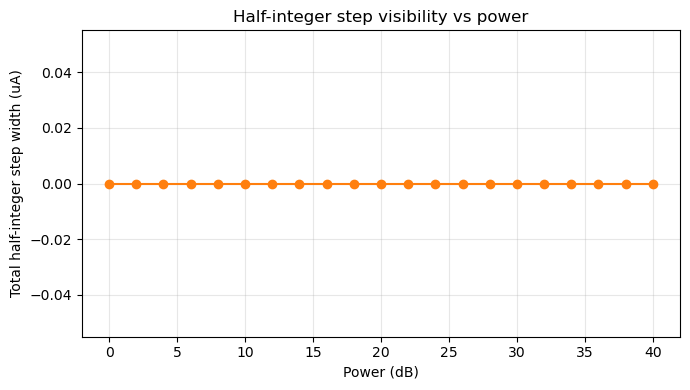

No half-integer steps detected in this power range.
Ratio I2/I_total = 0.10 → no visible half steps


In [ ]:
from scipy.special import jv
from scipy.stats import pearsonr
from mpl_toolkits.mplot3d import Axes3D 

########### IV simulation for topological junction: uses 2nd harmonic contribution ########################################################################

def simulate_IV_RCSJ_two_harmonics(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, noise,
        C, T, n_periods,
        steps_per_period=200, n_transient_periods=50):
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)

    dt = (1.0 / frequency) / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    n_transient = int(n_transient_periods * steps_per_period)

    I0 = np.asarray(I0, dtype=float)
    phi = np.zeros_like(I0)
    dphidt = np.zeros_like(I0)
    V_sum = np.zeros_like(I0)
    count = 0
    t = 0.0

    noise_T_amp = np.sqrt(2 * kb * T / (R * dt)) if T > 0 else 0.0

    for s in range(n_steps):
        I_N = noise_T_amp * np.random.randn(I0.size) if T > 0 else 0.0
        I_F = (noise * np.random.randn(I0.size) * (I0 + Irf_val / 1000.0)
               if noise > 0 else 0.0)

        I_s = I_crit1 * np.sin(phi) + I_crit2 * np.sin(2.0 * phi)

        I_drive = I0 + Irf_val * np.sin(2.0 * np.pi * frequency * t) \
                  - I_s + I_N + I_F

        if C > 0:
            d2phidt2 = (2.0 * e / (hbar * C)) * I_drive - dphidt / (R * C)
            dphidt = dphidt + dt * d2phidt2
        else:
            dphidt = (2.0 * e * R / hbar) * I_drive

        phi = phi + dt * dphidt

        if s >= n_transient:
            V_sum += (hbar / (2.0 * e)) * dphidt
            count += 1

        t += dt

    v_avg = V_sum / count
    nth_step = (v_avg * 2.0 * e) / (hbar * 2.0 * np.pi * frequency)

    return nth_step, v_avg

########### Step detection ####################################################################################################################

def extract_integer_and_half_steps(I0, nth_step, tol=0.05, min_points=8,
                                    flatness_tol=None):
    if flatness_tol is None:
        flatness_tol = tol / 2.0

    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest_half = np.round(2.0 * nth_step) / 2.0
    residual = np.abs(nth_step - nearest_half)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue

        n_val = nearest_half[i]
        j = i
        while j < N and on_plateau[j] and nearest_half[j] == n_val:
            j += 1

        if (j - i) >= min_points:
            segment = nth_step[i:j]
            if np.std(segment) < flatness_tol:
                I0_min = I0[i]
                I0_max = I0[j - 1]
                width = I0_max - I0_min

                if n_val not in widths or width > widths[n_val]:
                    widths[n_val] = width
                    ranges[n_val] = (I0_min, I0_max)

        i = j

    return widths, ranges

########### determine which values have half integer steps #############################################################################
def has_half_integer_step(widths):
    """True if any of the extracted plateaus is a genuine half-integer
    (not integer) step index."""
    return any(not np.isclose(n, np.round(n)) for n in widths)


####### power sweep #####################################################################################################################
def scan_power_and_plot_half_steps(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1):
    """
    vary the rf power then use the step extraction function to detect the steps for each power

    """
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(power_values), max(power_values))

    results = {}
    hit_flags = []

    for P in power_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(          ## call simulation function
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(           ## extract the widths
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        results[P] = (nth_step, v_avg, widths, ranges)             ## get the results for each power
        hit_flags.append(has_half_integer_step(widths))

        color = cmap(norm(P))
        ax.plot(I0 * 1e3, nth_step, color=color, lw=1.2)

    ## find first power where there are consecutive flat values of the voltage
    onset_power = None
    powers_sorted = sorted(power_values)
    hit_by_power = dict(zip(power_values, hit_flags))
    hits_sorted = [hit_by_power[P] for P in powers_sorted]
    
    for idx in range(len(hits_sorted) - require_consecutive + 1):
        if all(hits_sorted[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")

    if onset_power is not None:

        ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, lw=1)
        ax.text(ax.get_xlim()[1], 0.5, "  n = 1/2", va='center', fontsize=9)
        ax.set_title(
            f"Shapiro step evolution with power sweep\n"
            f"Half-integer steps first appear at P = {onset_power:.1f} dB"
        )
    else:
        ax.set_title("Shapiro step evolution with power sweep\n"
                      "No half-integer steps detected in this power range")

    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    ## plot the step power against the number of steps
    powers_arr = np.array(powers_sorted)
    half_metric = []
    for P in powers_sorted:
        _, _, widths, _ = results[P]
        half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
        half_metric.append(sum(widths[n] for n in half_ns) * 1e6 if half_ns else 0.0)
    half_metric = np.array(half_metric)

    plt.figure(figsize=(7, 4))
    plt.plot(powers_arr, half_metric, 'o-', color='tab:orange')
    if onset_power is not None:
        plt.axvline(onset_power, color='k', linestyle='--', alpha=0.6,
                    label=f"onset = {onset_power:.1f} dB")
        plt.legend()
    plt.xlabel("Power (dB)")
    plt.ylabel("Total half-integer step width (uA)")
    plt.title("Half-integer step visibility vs power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    return results, onset_power


## practice run: uses junction 1

powers = np.linspace(0, 40, 21)

## practice with temperature and noise = 0
print("=== ratio 4:1 (I_crit1 : I_crit2), noise/thermal OFF ===")
results_41, onset_41 = scan_power_and_plot_half_steps(
        R=junction1["R"],
        I_crit1=0.8 * junction1["I_crit"],
        I_crit2=0.2 * junction1["I_crit"],
        frequency=junction1["frequency"],
        I0=junction1["I0"],
        c_calib=1.0,
        noise=0.0,
        C=0.0,
        T=0.0,
        n_periods=500,
        power_values=powers,
    )

print("=== ratio 3:2 (I_crit1 : I_crit2), noise/thermal OFF ===")
results_32, onset_32 = scan_power_and_plot_half_steps(
        R=junction1["R"],
        I_crit1=0.6 * junction1["I_crit"],
        I_crit2=0.4 * junction1["I_crit"],
        frequency=junction1["frequency"],
        I0=junction1["I0"],
        c_calib=1.0,
        noise=0.0,
        C=0.0,
        T=0.0,
        n_periods=500,
        power_values=powers,
    )


##### Sweep through different ratios of I1 to I2 (different harmonic contributions) ####################################################################

def scan_ratios_and_detect_onset(
        R, I_crit_total, frequency, I0, c_calib,         ## defined junction parameters
        noise, C, T,                                     ## variable environment parameters
        n_periods,                                       ## input integration periods    
        power_values, ratio_values,                      ## variable simulation parameters
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, noise_threshold=1e-6):


    onset_map = {}
    half_widths = {}

    for r in ratio_values:                  ## get the values of each critical current given a certain ratio
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total

        results, onset_power = scan_power_and_plot_half_steps(     ## call scanning function
            R=R,
            I_crit1=I_crit1,
            I_crit2=I_crit2,
            frequency=frequency,
            I0=I0,
            c_calib=c_calib,
            noise=noise,
            C=C,
            T=T,
            n_periods=n_periods,
            power_values=power_values,
            tol=tol,
            min_points=min_points,
            flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )


        powers_sorted = sorted(power_values)                                 ## quantify the steps at each power
        widths_vs_power = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            total_half_width = sum(widths[n] for n in half_ns)
            widths_vs_power.append(total_half_width)

        half_widths[r] = np.array(widths_vs_power)

        ####################################################################################
        #### find the onset above the noise threshhold 
        ####
        visible = np.array(widths_vs_power) > noise_threshold            
        onset_idx = np.argmax(visible)
        onset_map[r] = powers_sorted[onset_idx] if visible.any() else None

        print(f"Ratio I2/I_total = {r:.2f} → onset power = "
              f"{onset_map[r]:.1f} dB" if onset_map[r] else
              f"Ratio I2/I_total = {r:.2f} → no visible half steps")
    
    ## plotting 
    plt.figure(figsize=(7, 4))
    ratios = np.array(list(onset_map.keys()))
    onsets = np.array([onset_map[r] if onset_map[r] is not None else np.nan
                       for r in ratios])
    plt.plot(ratios, onsets, 'o-', color='tab:red')
    plt.xlabel("Second harmonic ratio (I₂ / I_total)")
    plt.ylabel("Onset power (dB)")
    plt.title("Half-integer step onset vs harmonic ratio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return onset_map, half_widths

### call function for junction 1

powers = np.linspace(0, 40, 21)
ratios = np.linspace(0.0, 1, 11)  # vary second harmonic strength

onset_map, half_widths = scan_ratios_and_detect_onset(
        R=junction1["R"],
        I_crit_total=junction1["I_crit"],
        frequency=junction1["frequency"],
        I0=junction1["I0"],
        c_calib=1.0,
        noise=1e-6,  ## random dimensionless noise parameter
        C=0.0,
        T=4.2,
        n_periods=500,
        power_values=powers,
        ratio_values=ratios,
        noise_threshold=5e-6,  ## small noise threshhold (microamps)
    )


##### Comparing effects of different ratios
def sweep_ratios_and_summarize(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1,
        noise_threshold=5e-6):
    '''
    for each harmonic ratio r = I_crit2 / I_crit_total:
      - sweep powers
      - detect half-integer onset above noise threshold
      - record width of first half integer step
      - calculate Bessel prediction for ΔI_1/2
      - return a summary table

    '''

    summary = []

    for r in ratio_values:
        I_crit2 = r * I_crit_total
        I_crit1 = (1 - r) * I_crit_total

        ## run power sweep
        results, onset_power = scan_power_and_plot_half_steps(
            R=R,
            I_crit1=I_crit1,
            I_crit2=I_crit2,
            frequency=frequency,
            I0=I0,
            c_calib=c_calib,
            noise=noise,
            C=C,
            T=T,
            n_periods=n_periods,
            power_values=power_values,
            tol=tol,
            min_points=min_points,
            flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )

        ## calculate step width vs power ##
        powers_sorted = sorted(power_values)
        half_widths = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            total_half_width = sum(widths[n] for n in half_ns)
            half_widths.append(total_half_width)

        half_widths = np.array(half_widths)

        ## calculate the onset ##
        visible = half_widths > noise_threshold
        if visible.any():
            idx = np.argmax(visible)
            onset = powers_sorted[idx]
            first_width = half_widths[idx]
        else:
            onset = None
            first_width = 0.0

        ## find bessel function prediction
        import scipy.special as sp

        if onset is not None:
            Irf = c_calib * (I_crit1 + I_crit2) * 10 ** ((onset - 20) / 20)
            a = Irf / (I_crit1 + I_crit2)
            bessel_pred = 2 * I_crit2 * abs(sp.jv(1, a))
        else:
            bessel_pred = 0.0

        summary.append(dict(
            ratio=r,
            onset_power=onset,
            first_half_width=first_width,
            bessel_predicted_width=bessel_pred
        ))

    return summary

ratios = np.linspace(0.0, 1, 11)
powers = np.linspace(0, 40, 21)

summary = sweep_ratios_and_summarize(
    R=junction["R"],
    I_crit_total=junction["I_crit"],
    frequency=junction["frequency"],
    I0=junction["I0"],
    c_calib=1.0,
    noise=1e-6,
    C=0.0,
    T=4.2,
    n_periods=500,
    power_values=powers,
    ratio_values=ratios,
    noise_threshold=5e-6
)

def extract_integer_and_half_steps(I0, nth_step, tol=0.05, min_points=8,
                                    flatness_tol=None):
    if flatness_tol is None:
        flatness_tol = tol / 2.0

    I0 = np.asarray(I0)
    nth_step = np.asarray(nth_step)

    nearest_half = np.round(2.0 * nth_step) / 2.0
    residual = np.abs(nth_step - nearest_half)
    on_plateau = residual < tol

    widths = {}
    ranges = {}

    i = 0
    N = len(I0)
    while i < N:
        if not on_plateau[i]:
            i += 1
            continue

        n_val = nearest_half[i]
        j = i
        while j < N and on_plateau[j] and nearest_half[j] == n_val:
            j += 1

        if (j - i) >= min_points:
            segment = nth_step[i:j]
            if np.std(segment) < flatness_tol:
                I0_min = I0[i]
                I0_max = I0[j - 1]
                width = I0_max - I0_min

                if n_val not in widths or width > widths[n_val]:
                    widths[n_val] = width
                    ranges[n_val] = (I0_min, I0_max)

        i = j

    return widths, ranges


def has_half_integer_step(widths):
    return any(not np.isclose(n, np.round(n)) for n in widths)


def _half_width_sum(widths):
    """Total width tied up in genuine half-integer plateaus."""
    half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
    return sum(widths[n] for n in half_ns)


############### Power sweep and plot ###########################################################################

def scan_power_and_plot_half_steps(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, savepath=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.get_cmap("plasma")
    norm = plt.Normalize(min(power_values), max(power_values))

    results = {}
    hit_flags = []

    for P in power_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        results[P] = (nth_step, v_avg, widths, ranges)
        hit_flags.append(has_half_integer_step(widths))

        color = cmap(norm(P))
        ax.plot(I0 * 1e3, nth_step, color=color, lw=1.2)

    onset_power = None
    powers_sorted = sorted(power_values)
    hit_by_power = dict(zip(power_values, hit_flags))
    hits_sorted = [hit_by_power[P] for P in powers_sorted]
    for idx in range(len(hits_sorted) - require_consecutive + 1):
        if all(hits_sorted[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Power (dB)")

    if onset_power is not None:
        ax.axhline(0.5, color='k', linestyle=':', alpha=0.4, lw=1)
        ax.text(ax.get_xlim()[1], 0.5, "  n = 1/2", va='center', fontsize=9)
        ax.set_title(
            f"Shapiro step evolution with power sweep\n"
            f"Half-integer steps first appear at P = {onset_power:.1f} dB"
        )
    else:
        ax.set_title("Shapiro step evolution with power sweep\n"
                      "No half-integer steps detected in this power range")

    ax.set_xlabel("Current (mA)")
    ax.set_ylabel(r"Step number $n = 2eV/hf_{rf}$")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    powers_arr = np.array(powers_sorted)
    half_metric = []
    for P in powers_sorted:
        _, _, widths, _ = results[P]
        half_metric.append(_half_width_sum(widths) * 1e6)
    half_metric = np.array(half_metric)

    plt.figure(figsize=(7, 4))
    plt.plot(powers_arr, half_metric, 'o-', color='tab:orange')
    if onset_power is not None:
        plt.axvline(onset_power, color='k', linestyle='--', alpha=0.6,
                    label=f"onset = {onset_power:.1f} dB")
        plt.legend()
    plt.xlabel("Power (dB)")
    plt.ylabel("Total half-integer step width (uA)")
    plt.title("Half-integer step visibility vs power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath.replace(".png", "_visibility.png"), dpi=150)
    plt.show()

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    return results, onset_power


def scan_ratios_and_detect_onset(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, noise_threshold=1e-6):
    onset_map = {}
    half_widths = {}
    for r in ratio_values:
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        results, onset_power = scan_power_and_plot_half_steps(
            R=R, I_crit1=I_crit1, I_crit2=I_crit2, frequency=frequency,
            I0=I0, c_calib=c_calib, noise=noise, C=C, T=T,
            n_periods=n_periods, power_values=power_values,
            tol=tol, min_points=min_points, flatness_tol=flatness_tol,
            require_consecutive=require_consecutive,
        )
        powers_sorted = sorted(power_values)
        widths_vs_power = []
        for P in powers_sorted:
            _, _, widths, _ = results[P]
            widths_vs_power.append(_half_width_sum(widths))
        half_widths[r] = np.array(widths_vs_power)

        visible = np.array(widths_vs_power) > noise_threshold
        onset_idx = np.argmax(visible)
        onset_map[r] = powers_sorted[onset_idx] if visible.any() else None
        msg = (f"Ratio I2/I_total = {r:.2f} -> onset power = "
               f"{onset_map[r]:.1f} dB" if onset_map[r] is not None else
               f"Ratio I2/I_total = {r:.2f} -> no visible half steps")
        print(msg)

    plt.figure(figsize=(7, 4))
    ratios = np.array(list(onset_map.keys()))
    onsets = np.array([onset_map[r] if onset_map[r] is not None else np.nan
                        for r in ratios])
    plt.plot(ratios, onsets, 'o-', color='tab:red')
    plt.xlabel("Second harmonic ratio (I2 / I_total)")
    plt.ylabel("Onset power (dB)")
    plt.title("Half-integer step onset vs harmonic ratio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return onset_map, half_widths


## bessel function predicted step widths ##
def bessel_predicted_step_widths(I_crit1, I_crit2, R, frequency, power,
                                  c_calib, max_n=3):
    '''
    RSJ prediction: calculate the predicted step widths
    '''
    Irf_val = c_calib * (I_crit1 + I_crit2) * 10 ** ((power - 20) / 20)
    alpha1 = 2 * e * Irf_val * R / (h * frequency)
    alpha2 = 2 * alpha1

    widths = {}
    for n in range(-max_n, max_n + 1):
        widths[float(n)] = 2 * I_crit1 * abs(jv(n, alpha1))
    for m in range(-2 * max_n, 2 * max_n + 1):
        n_half = m / 2.0
        if np.isclose(n_half, np.round(n_half)):
            continue
        widths[n_half] = 2 * I_crit2 * abs(jv(m, alpha2))

    return widths, alpha1, alpha2


################ simulate the predicted values from the bessel function expected #############################################
def compare_bessel_vs_simulated(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values,
        tol=0.05, min_points=8, flatness_tol=None, max_n=3,
        savepath=None):
    '''
    plot the bessel function predicted step widths
    '''
    powers_sorted = sorted(power_values)

    sim_int, sim_half = [], []
    pred_int, pred_half = [], []
    alphas1, alphas2 = [], []

    for P in powers_sorted:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        pred, a1, a2 = bessel_predicted_step_widths(
            I_crit1, I_crit2, R, frequency, P, c_calib, max_n=max_n)

        sim_int.append(widths.get(1.0, 0.0))
        sim_half.append(widths.get(0.5, 0.0))
        pred_int.append(pred.get(1.0, 0.0))
        pred_half.append(pred.get(0.5, 0.0))
        alphas1.append(a1)
        alphas2.append(a2)

    sim_int, sim_half = np.array(sim_int), np.array(sim_half)
    pred_int, pred_half = np.array(pred_int), np.array(pred_half)
    powers_arr = np.array(powers_sorted)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(powers_arr, pred_int * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[0].plot(powers_arr, sim_int * 1e6, 'o-', color='tab:blue',
                 label='Simulated')
    axes[0].set_title("n = 1 (integer) step width")
    axes[0].set_xlabel("Power (dB)")
    axes[0].set_ylabel("Step width (uA)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(powers_arr, pred_half * 1e6, '--', color='k',
                 label='Bessel prediction')
    axes[1].plot(powers_arr, sim_half * 1e6, 'o-', color='tab:orange',
                 label='Simulated')
    axes[1].set_title("n = 1/2 (half-integer) step width")
    axes[1].set_xlabel("Power (dB)")
    axes[1].set_ylabel("Step width (uA)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    def _summary(sim, pred, label):

        mask = pred > 1e-9
        out = dict(label=label)
        if mask.sum() >= 2:
            r, _ = pearsonr(sim[mask], pred[mask])
            out['pearson_r'] = r
        else:
            out['pearson_r'] = np.nan
        rmse = np.sqrt(np.mean((sim - pred) ** 2))
        out['rmse_uA'] = rmse * 1e6
        denom = np.mean(pred[mask]) if mask.sum() else np.nan
        out['normalized_rmse'] = (rmse / denom) if denom else np.nan
        out['mean_sim_uA'] = np.mean(sim) * 1e6
        out['mean_pred_uA'] = np.mean(pred) * 1e6
        return out

    summary = {
        'n1': _summary(sim_int, pred_int, 'n=1'),
        'n_half': _summary(sim_half, pred_half, 'n=1/2'),
    }

    print("Quantitative comparison, simulated vs Bessel prediction")
    print("-" * 58)
    for key, s in summary.items():
        print(f"  {s['label']:>6s}:  Pearson r = {s['pearson_r']:.3f}   "
              f"RMSE = {s['rmse_uA']:.3f} uA   "
              f"normalized RMSE = {s['normalized_rmse']:.3f}   "
              f"(mean sim = {s['mean_sim_uA']:.3f} uA, "
              f"mean predicted = {s['mean_pred_uA']:.3f} uA)")

    return dict(powers=powers_arr, sim_int=sim_int, sim_half=sim_half,
                pred_int=pred_int, pred_half=pred_half,
                alpha1=np.array(alphas1), alpha2=np.array(alphas2),
                summary=summary)


###### Evaluating how clear the shapiro steps are when temperature is changed ############################################################
def evaluate_clarity_vs_temperature(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib,
        noise, C, n_periods, T_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    changes temperature and evaluates how clear the shapiro steps are.

      - n_plateaus: how many distinct integer/half-integer plateaus survive
        the flatness test at this T (thermal noise smears/kills plateaus)
      - jaggedness: std of point-to-point differences in nth_step, i.e. how
        noisy the raw I-V trace is (lower = cleaner staircase)
      - total_half_width: the quantity you probably care most about --
        does the half-integer feature survive thermal smearing at all
    """
    records = []
    traces = {}

    for T in T_values:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, power, I0, c_calib,
            noise, C, T, n_periods)
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)

        dn = np.diff(nth_step)
        jaggedness = np.std(dn)

        records.append(dict(
            T=T,
            n_plateaus=len(widths),
            jaggedness=jaggedness,
            total_half_width_uA=_half_width_sum(widths) * 1e6,
            has_half_step=has_half_integer_step(widths),
        ))
        traces[T] = nth_step

    Ts = np.array([r['T'] for r in records])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    cmap = plt.get_cmap("coolwarm")
    norm = plt.Normalize(min(T_values), max(T_values))
    for T in T_values:
        axes[0].plot(I0 * 1e3, traces[T], color=cmap(norm(T)), lw=1.0)
    axes[0].set_xlabel("Current (mA)")
    axes[0].set_ylabel(r"$n = 2eV/hf_{rf}$")
    axes[0].set_title("I-V staircase vs T")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes[0], label="T (K)")

    axes[1].plot(Ts, [r['jaggedness'] for r in records], 'o-', color='tab:red')
    axes[1].set_xlabel("T (K)")
    axes[1].set_ylabel("Trace jaggedness (std of dn/dI0)")
    axes[1].set_title("Staircase noise vs T")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(Ts, [r['n_plateaus'] for r in records], 's-',
                 color='tab:green', label='# plateaus found')
    ax2b = axes[2].twinx()
    ax2b.plot(Ts, [r['total_half_width_uA'] for r in records], 'd--',
              color='tab:orange', label='total half-step width (uA)')
    axes[2].set_xlabel("T (K)")
    axes[2].set_ylabel("# plateaus", color='tab:green')
    ax2b.set_ylabel("half-step width (uA)", color='tab:orange')
    axes[2].set_title("Plateau count & half-step survival vs T")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    print("Clarity vs temperature")
    print("-" * 58)
    for r in records:
        print(f"  T = {r['T']:6.2f} K   plateaus = {r['n_plateaus']:2d}   "
              f"jaggedness = {r['jaggedness']:.4f}   "
              f"half-width = {r['total_half_width_uA']:.3f} uA   "
              f"half-step present: {r['has_half_step']}")

    return records


## visualisation: 3d sweep of harmonic ratio vs step width    ########################################################################################
def plot_ratio_power_width_3d(
        R, I_crit_total, frequency, I0, c_calib,
        noise, C, T, n_periods, power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None, savepath=None):
    """
    For each ratio r = Ic2/Ic_total, sweeps power and computes the total
    half-integer step width. Plots one curve per ratio, each on its own
    "ratio plane" of a 3D (power, ratio, width) plot.
    """
    powers_sorted = np.array(sorted(power_values))
    ratios_sorted = np.array(sorted(ratio_values))

    fig = plt.figure(figsize=(10, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(ratios_sorted.min(), ratios_sorted.max())

    width_grid = np.zeros((len(ratios_sorted), len(powers_sorted)))

    for ri, r in enumerate(ratios_sorted):
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total
        row = []
        for P in powers_sorted:
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, P, I0, c_calib,
                noise, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            row.append(_half_width_sum(widths) * 1e6)
        row = np.array(row)
        width_grid[ri] = row

        ax.plot(powers_sorted, np.full_like(powers_sorted, r), row,
                color=cmap(norm(r)), lw=1.8)

    ax.set_xlabel("Power (dB)")
    ax.set_ylabel("Ic2 / Ic_total ratio")
    ax.set_zlabel("Total half-step width (uA)")
    ax.set_title("Half-integer Shapiro step width vs power and harmonic ratio")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.6, label="ratio")

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

    return powers_sorted, ratios_sorted, width_grid


## determine the noise amplitude that washes out the half integer steps
def find_critical_noise_amplitude(
        R, I_crit1, I_crit2, frequency, power, I0, c_calib, C, T, n_periods,
        noise_lo=0.0, noise_hi=0.05, iterations=6, n_repeats=1,
        tol=0.005, min_points=8, flatness_tol=None):

    def step_survives(noise_val):
        survived = 0
        for _ in range(n_repeats):
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, power, I0, c_calib,
                noise_val, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            if has_half_integer_step(widths):
                survived += 1
        return survived > n_repeats / 2.0

    if not step_survives(noise_lo):
        return 0.0
    if step_survives(noise_hi):
        return noise_hi

    lo, hi = noise_lo, noise_hi
    for _ in range(iterations):
        mid = 0.5 * (lo + hi)
        if step_survives(mid):
            lo = mid
        else:
            hi = mid
    return lo


## summarise by each ratio ########################################################################################

def build_shapiro_ratio_summary_table(
        R, I_crit_total, frequency, I0, c_calib, C, T, n_periods,
        power_values, ratio_values,
        tol=0.05, min_points=8, flatness_tol=None, max_n=3,
        noise_hi=0.05, noise_iterations=6, noise_n_repeats=1,
        power_above_onset=4.0, savepath_csv=None, savepath_fig=None):
    """
    For each ratio r = Ic2/Ic_total, builds one row of:

      - onset_power_dB       : first power (in `power_values`) where a
                                genuine half-integer plateau appears
                                (noise=0 baseline, at the given T)
      - sim_half_width_uA    : simulated half-step width at onset
      - bessel_half_width_uA : Bessel-predicted half-step width at onset
                                (see bessel_predicted_step_widths)
      - deviation_uA / deviation_pct : simulated - predicted, and as a
                                percentage of the predicted width
      - test_power_dB        : power used for the noise-tolerance test
                                (onset + power_above_onset, so the step is
                                already well-established rather than
                                marginal)
      - critical_noise_amp   : largest `noise` amplitude the half-step
                                survives at test_power_dB (see
                                find_critical_noise_amplitude)

    Ratios where no half-integer step appears anywhere in `power_values`
    get NaNs for everything downstream of onset.

    Requires pandas. Returns the DataFrame; also prints it and optionally
    saves it to CSV / plots it.
    """

    powers_sorted = sorted(power_values)
    max_power = max(powers_sorted)
    rows = []

    for r in ratio_values:
        I_crit1 = (1 - r) * I_crit_total
        I_crit2 = r * I_crit_total

        onset_power = None
        sim_width = np.nan
        for P in powers_sorted:
            nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
                R, I_crit1, I_crit2, frequency, P, I0, c_calib,
                0.0, C, T, n_periods)
            widths, ranges = extract_integer_and_half_steps(
                I0, nth_step, tol=tol, min_points=min_points,
                flatness_tol=flatness_tol)
            half_ns = [n for n in widths if not np.isclose(n, np.round(n))]
            if half_ns:
                onset_power = P
                sim_width = max(widths[n] for n in half_ns)
                break

        if onset_power is None:
            rows.append(dict(
                ratio=r, I_crit1_uA=I_crit1 * 1e6, I_crit2_uA=I_crit2 * 1e6,
                onset_power_dB=np.nan, sim_half_width_uA=np.nan,
                bessel_half_width_uA=np.nan, deviation_uA=np.nan,
                deviation_pct=np.nan, test_power_dB=np.nan,
                critical_noise_amp=np.nan,
            ))
            print(f"ratio={r:.2f}: no half-integer step found in power range "
                  f"-- skipping deviation/noise-tolerance evaluation")
            continue

        pred, a1, a2 = bessel_predicted_step_widths(
            I_crit1, I_crit2, R, frequency, onset_power, c_calib, max_n=max_n)
        pred_width = pred.get(0.5, 0.0)
        deviation = sim_width - pred_width
        deviation_pct = (deviation / pred_width * 100.0) if pred_width > 0 else np.nan

        test_power = min(onset_power + power_above_onset, max_power)
        crit_noise = find_critical_noise_amplitude(
            R, I_crit1, I_crit2, frequency, test_power, I0, c_calib, C, T,
            n_periods, noise_lo=0.0, noise_hi=noise_hi,
            iterations=noise_iterations, n_repeats=noise_n_repeats,
            tol=tol, min_points=min_points, flatness_tol=flatness_tol)

        rows.append(dict(
            ratio=r, I_crit1_uA=I_crit1 * 1e6, I_crit2_uA=I_crit2 * 1e6,
            onset_power_dB=onset_power, sim_half_width_uA=sim_width * 1e6,
            bessel_half_width_uA=pred_width * 1e6, deviation_uA=deviation * 1e6,
            deviation_pct=deviation_pct, test_power_dB=test_power,
            critical_noise_amp=crit_noise,
        ))
        print(f"ratio={r:.2f}: onset={onset_power:.1f} dB, "
              f"sim={sim_width*1e6:.2f} uA, bessel={pred_width*1e6:.2f} uA, "
              f"deviation={deviation*1e6:+.2f} uA ({deviation_pct:+.1f}%), "
              f"critical noise amp @ {test_power:.1f} dB = {crit_noise:.5f}")

    df = pd.DataFrame(rows)
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    print("\nSummary table")
    print(df.to_string(index=False))

    if savepath_csv:
        df.to_csv(savepath_csv, index=False)

    ## summary plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].plot(df['ratio'], df['onset_power_dB'], 'o-', color='tab:blue')
    axes[0].set_xlabel("Ic2 / Ic_total ratio")
    axes[0].set_ylabel("Onset power (dB)")
    axes[0].set_title("Half-step onset power vs ratio")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df['ratio'], df['deviation_pct'], 'o-', color='tab:red')
    axes[1].axhline(0, color='k', lw=0.8, alpha=0.5)
    axes[1].set_xlabel("Ic2 / Ic_total ratio")
    axes[1].set_ylabel("Deviation from Bessel prediction (%)")
    axes[1].set_title("Simulated vs predicted deviation vs ratio")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df['ratio'], df['critical_noise_amp'], 'o-', color='tab:green')
    axes[2].set_xlabel("Ic2 / Ic_total ratio")
    axes[2].set_ylabel("Critical noise amplitude")
    axes[2].set_title("Noise tolerance vs ratio")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath_fig:
        plt.savefig(savepath_fig, dpi=150)
    plt.show()

    return df
junction = junction1

I0_demo = np.linspace(-0.6e-3, 0.6e-3, 1000)
powers_demo = np.linspace(0, 40, 11)
ratios_demo = np.linspace(0.0, 1.01, 10)
n_periods_demo = 150
min_points_demo = 5

#######
####### Practice run
#######
I_crit1 = 0.6 * junction1["I_crit"]
I_crit2 = 0.4 * junction1["I_crit"]

print("\n=== 1. Simulated vs Bessel-predicted step widths ===")
cmp_result = compare_bessel_vs_simulated(
        R=junction1["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction1["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, min_points=min_points_demo)

print("\n=== 2. Shapiro step clarity vs temperature ===")
T_values_demo = [0.0, 1.0, 2.0, 4.2, 8.0]
clarity_records = evaluate_clarity_vs_temperature(
        R=junction1["R"], I_crit1=I_crit1, I_crit2=I_crit2,
        frequency=junction1["frequency"], power=32.0, I0=I0_demo,
        c_calib=1.0, noise=1e-6, C=0.0, n_periods=n_periods_demo,
        T_values=T_values_demo, min_points=min_points_demo)

print("\n=== 3. 3D sweep: power x ratio x half-step width ===")
powers_3d, ratios_3d, width_grid = plot_ratio_power_width_3d(
        R=junction1["R"], I_crit_total=junction1["I_crit"],
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        noise=0.0, C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, ratio_values=ratios_demo,
        min_points=min_points_demo)

print("\n=== 4. Per-ratio summary table ===")
ratios_table_demo = np.linspace(0.1, 1.001, 11)
summary_df = build_shapiro_ratio_summary_table(
        R=junction1["R"], I_crit_total=junction["I_crit"],
        frequency=junction["frequency"], I0=I0_demo, c_calib=1.0,
        C=0.0, T=0.0, n_periods=n_periods_demo,
        power_values=powers_demo, ratio_values=ratios_table_demo,
        min_points=min_points_demo,
        noise_hi=0.02, noise_iterations=5, noise_n_repeats=1,
        power_above_onset=4.0)

In [ ]:
import plotly.graph_objects as go
import plotly.colors as pc
def plot_3d(
        R, I_crit1, I_crit2, frequency, I0, c_calib,
        noise, C, T, n_periods,
        power_values, tol=0.05, min_points=8, flatness_tol=None,
        require_consecutive=1, cmap_name="Plasma"):


    powers_sorted = sorted(power_values)
    results = {}
    hit_flags = []

    for P in powers_sorted:
        nth_step, v_avg = simulate_IV_RCSJ_two_harmonics(
            R, I_crit1, I_crit2, frequency, P, I0, c_calib,
            noise, C, T, n_periods
        )
        widths, ranges = extract_integer_and_half_steps(
            I0, nth_step, tol=tol, min_points=min_points,
            flatness_tol=flatness_tol)
        results[P] = (nth_step, v_avg, widths, ranges)
        hit_flags.append(has_half_integer_step(widths))

    onset_power = None
    for idx in range(len(hit_flags) - require_consecutive + 1):
        if all(hit_flags[idx:idx + require_consecutive]):
            onset_power = powers_sorted[idx]
            break

    I0_mA = np.asarray(I0) * 1e3
    pmin, pmax = min(powers_sorted), max(powers_sorted)

    def color_for(P):
        frac = 0.0 if pmax == pmin else (P - pmin) / (pmax - pmin)
        return pc.sample_colorscale(cmap_name, frac)[0]

    fig = go.Figure()

    for P in powers_sorted:
        nth_step, v_avg, widths, ranges = results[P]
        is_onset = onset_power is not None and np.isclose(P, onset_power)
        fig.add_trace(go.Scatter3d(
            x=I0_mA,
            y=np.full_like(I0_mA, P),
            z=nth_step,
            mode='lines',
            line=dict(color=color_for(P), width=6 if is_onset else 3),
            name=f"P = {P:.1f} dB" + ("  (onset)" if is_onset else ""),
            hovertemplate=(
                "I0 = %{x:.4f} mA<br>"
                f"Power = {P:.1f} dB<br>"
                "n = %{z:.3f}<extra></extra>"
            ),
        ))

    half_x, half_y, half_z = [], [], []
    for P in powers_sorted:
        half_x += [I0_mA.min(), I0_mA.max(), None]
        half_y += [P, P, None]
        half_z += [0.5, 0.5, None]
    fig.add_trace(go.Scatter3d(
        x=half_x, y=half_y, z=half_z, mode='lines',
        line=dict(color='black', width=2, dash='dot'),
        opacity=0.3, name="n = 1/2 (reference)", hoverinfo='skip',
    ))

    ###### show the onset power #####################
    if onset_power is not None:
        fig.add_trace(go.Scatter3d(
            x=[I0_mA.min(), I0_mA.max()],
            y=[onset_power, onset_power],
            z=[0.5, 0.5],
            mode='lines',
            line=dict(color='black', width=8, dash='dash'),
            name=f"n=1/2 onset, P={onset_power:.1f} dB",
        ))
        z_all = np.concatenate([results[P][0] for P in powers_sorted])
        z_min, z_max = float(np.nanmin(z_all)), float(np.nanmax(z_all))
        fig.add_trace(go.Scatter3d(
            x=[I0_mA.max(), I0_mA.max()],
            y=[onset_power, onset_power],
            z=[z_min, z_max],
            mode='lines',
            line=dict(color='black', width=4, dash='dash'),
            opacity=0.6, showlegend=False, hoverinfo='skip',
        ))

    title = "Shapiro step evolution vs power (interactive 3D waterfall)"
    if onset_power is not None:
        title += f"<br><sup>Half-integer steps first appear at P = {onset_power:.1f} dB</sup>"
    else:
        title += "<br><sup>No half-integer steps detected in this power range</sup>"

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="Current (mA)",
            yaxis_title="Power (dB)",
            zaxis_title="Step number n = 2eV/hf_rf",
        ),
        width=950, height=750,
        legend=dict(itemsizing='constant'),
    )

    if onset_power is not None:
        print(f"Half-integer steps first appear (and stay flat) around "
              f"P = {onset_power:.1f} dB.")
    else:
        print("No half-integer steps detected in this power range.")

    fig.show()
    return fig, results, onset_power


fig, results_3d, onset_3d = plot_3d(
    R=junction["R"],
    I_crit1=0.6 * junction["I_crit"],
    I_crit2=0.4 * junction["I_crit"],
    frequency=junction["frequency"],
    I0=junction["I0"],
    c_calib=1.0,
    noise=0.0,
    C=0.0,
    T=0.0,
    n_periods=500,
    power_values=powers,
)